## Signal A: Volume-Based Cross-Sectional Reversal

**Hypothesis.** Cross-sectional short-horizon reversal exists in liquid crypto: coins that have fallen the most over the past week tend to outperform coins that have risen the most over the same window. We want to use uninformed flow to find reversal. The original hypothesis conditioned this reversal on low contemporaneous volume (the idea being that low-volume moves are more likely to be uninformed and revert), but that gate was tested and falsified. See the Signal Construction section.

**Literature.** Fičura & Colak (2024) document short-horizon reversal in crypto, with the effect concentrated in low-volume names. The mechanism transfer to large-cap crypto with daily-or-faster rebalancing is partial: the same paper finds the effect weakens in liquid universes.

**Spec.** Cross-sectional reversal on the trailing 1-week return (42 4h-bars). Universe is the top-50 by trailing 30d dollar volume with hysteresis (entry top 50, exit top 70). Portfolio rebalances every 4h. A BTC realized-volatility regime gate (signal off when BTC 30d annualized vol exceeds 0.6) is the only conditioning filter retained. Cost assumption is 20 bps per turnover unit (market execution).

**Output.** A daily weights panel and a net-return series, persisted to `data/signal_a_v1_regime.pkl` for downstream combined-portfolio work.

In [28]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import time
from collections import Counter
import os
import pickle
import matplotlib.pyplot as plt

os.chdir('/Users/muditlam/Desktop/PythonJupyterCode/cryptoStatArbProject')

from quantlib import (
    rank_demean_normalize, compute_turnover, apply_costs,
    get_stats, factor_regression, drawdown,
    BARS_PER_YEAR_4H, DEFAULT_COST_BPS_MARKET,
)

print("Working directory:", os.getcwd())

PROJECT_DIR = os.path.dirname(os.path.abspath('DataPipeline.ipynb'))
PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'binance_ohlcv_panel_4h.pkl')

print(PANEL_DATA_PATH)
os.makedirs(os.path.dirname(PANEL_DATA_PATH), exist_ok=True)
print(f"Save path: {PANEL_DATA_PATH}")

FREQ = '4h'
START_TS = '2019-01-01'

panels = pickle.load(open(PANEL_DATA_PATH, 'rb'))

px = panels['px']
ret = panels['ret']
dvol = panels['dvol']
taker_buy_dvol = panels['taker_buy_dvol']
num_trades = panels['num_trades']
high_px = panels['high_px']
low_px = panels['low_px']
close_px = panels['close_px']
universe = panels['universe']
universe_daily = panels['universe_daily']
universe_monthly = panels['universe_monthly']
candidate_symbols = panels['candidate_symbols']

print(f"Loaded pickle. px: {px.shape}, ret: {ret.shape}), universe: {universe.shape}")


Working directory: /Users/muditlam/Desktop/PythonJupyterCode/classProject
/Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Save path: /Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Loaded pickle. px: (14417, 193), ret: (14417, 193)), universe: (14417, 193)


## Knobs to Turn

- N_BARS_FORMATION - formation window for returns for reversal
- N_BARS_VOL_WINDOW - formation window for trailing volume.

In [29]:
N_BARS_FORMATION = 7*6 # 4 Hour interval
N_BARS_VOL_WINDOW = 20*6 # 20 days
VOL_GATE_THRESHOLD = 0.7

## Compute the raw signal (negative of trailing 1-week return)

A week in 4h bars = 7 days * 6 bars = 42 bars

In [30]:
trailing_ret = ret.rolling(N_BARS_FORMATION).sum()
sig_raw = -1*trailing_ret
sig_raw


,1000MOGUSDT,1000REKTUSDT,1INCHUSDT,A2ZUSDT,AAVEUSDT,ACHUSDT,ADAUSDT,ADXUSDT,AIXBTUSDT,ALGOUSDT,...,XECUSDT,XLMUSDT,XNOUSDT,XRPUSDT,XTZUSDT,YFIUSDT,ZECUSDT,ZENUSDT,ZILUSDT,ZRXUSDT
2019-09-23 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-21 08:00:00,-0.325259,-0.750042,-0.067223,-0.572961,0.055151,-0.063848,-0.028722,-0.308006,-0.12153,0.060485,...,-0.324623,-0.156726,-0.137684,-0.052283,-0.081645,-0.050997,0.095945,-0.120329,-0.005753,-0.028053
2026-04-21 12:00:00,-0.310467,-0.750042,-0.067223,-0.332221,0.052242,-0.063848,-0.030352,-0.308006,-0.12153,0.044791,...,-0.166068,-0.131919,-0.203800,-0.042859,-0.073539,-0.083083,0.111884,-0.054477,-0.045455,-0.028977
2026-04-21 16:00:00,-0.270125,-0.750042,-0.039331,-0.332221,0.053139,-0.035984,-0.020679,-0.256585,-0.12153,0.045359,...,-0.166068,-0.133887,-0.196093,-0.042335,-0.015438,-0.083083,0.111220,-0.108116,-0.022971,-0.028977
2026-04-21 20:00:00,-0.276927,-0.750042,-0.048755,-0.381001,0.037457,-0.028022,-0.037111,-0.256585,-0.12153,0.050848,...,-0.302924,-0.162117,-0.196093,-0.051531,-0.015438,-0.083083,0.100914,-0.071433,-0.025548,-0.028977


## Compute volume ratio - today's volume vs trailing 20-day Average

In [31]:
vol_avg = dvol.rolling(N_BARS_VOL_WINDOW).mean()
vol_ratio = dvol/vol_avg
vol_ratio

,1000MOGUSDT,1000REKTUSDT,1INCHUSDT,A2ZUSDT,AAVEUSDT,ACHUSDT,ADAUSDT,ADXUSDT,AIXBTUSDT,ALGOUSDT,...,XECUSDT,XLMUSDT,XNOUSDT,XRPUSDT,XTZUSDT,YFIUSDT,ZECUSDT,ZENUSDT,ZILUSDT,ZRXUSDT
2019-09-23 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-21 08:00:00,0.111479,0.0,0.000000,0.000000,0.514217,0.000000,0.230229,0.0,0.0,0.184042,...,0.000000,0.500396,0.000000,0.201280,0.000000,0.0,1.091300,4.881700,0.127716,0.000000
2026-04-21 12:00:00,0.309979,0.0,0.000000,0.290327,0.998446,0.000000,0.329062,0.0,0.0,0.111185,...,1.339634,1.007693,0.000000,0.840569,0.231814,0.0,1.548521,6.045436,0.154853,0.000000
2026-04-21 16:00:00,1.587645,0.0,0.000000,0.809602,0.012212,11.872397,0.819260,0.0,0.0,0.154185,...,0.491380,0.997506,8.873937,0.253776,1.035007,0.0,0.669041,0.492015,1.240830,0.000000
2026-04-21 20:00:00,1.828188,0.0,1.102664,0.114822,0.329534,0.598851,0.109018,0.0,0.0,0.039944,...,0.000000,0.646195,10.960053,0.273929,0.000000,0.0,0.328715,0.017083,0.108951,0.000000


## Gate signal - long/short when volume is LOW (<0.7 AVG)

The idea is we want reversal to run on uninformed flow which is signaled by low volume trading days.

In [32]:

# The volume gate (gated_signal = sig_raw.where(vol_ratio < VOL_GATE_THRESHOLD, 0))
# was tested and falsified. See the Signal Construction section above.
gated_signal = sig_raw
gated_signal

,1000MOGUSDT,1000REKTUSDT,1INCHUSDT,A2ZUSDT,AAVEUSDT,ACHUSDT,ADAUSDT,ADXUSDT,AIXBTUSDT,ALGOUSDT,...,XECUSDT,XLMUSDT,XNOUSDT,XRPUSDT,XTZUSDT,YFIUSDT,ZECUSDT,ZENUSDT,ZILUSDT,ZRXUSDT
2019-09-23 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-21 08:00:00,-0.325259,-0.750042,-0.067223,-0.572961,0.055151,-0.063848,-0.028722,-0.308006,-0.12153,0.060485,...,-0.324623,-0.156726,-0.137684,-0.052283,-0.081645,-0.050997,0.095945,-0.120329,-0.005753,-0.028053
2026-04-21 12:00:00,-0.310467,-0.750042,-0.067223,-0.332221,0.052242,-0.063848,-0.030352,-0.308006,-0.12153,0.044791,...,-0.166068,-0.131919,-0.203800,-0.042859,-0.073539,-0.083083,0.111884,-0.054477,-0.045455,-0.028977
2026-04-21 16:00:00,-0.270125,-0.750042,-0.039331,-0.332221,0.053139,-0.035984,-0.020679,-0.256585,-0.12153,0.045359,...,-0.166068,-0.133887,-0.196093,-0.042335,-0.015438,-0.083083,0.111220,-0.108116,-0.022971,-0.028977
2026-04-21 20:00:00,-0.276927,-0.750042,-0.048755,-0.381001,0.037457,-0.028022,-0.037111,-0.256585,-0.12153,0.050848,...,-0.302924,-0.162117,-0.196093,-0.051531,-0.015438,-0.083083,0.100914,-0.071433,-0.025548,-0.028977


## Construct weights via rank-demean-normalize, masked by universe

In [33]:
weights = rank_demean_normalize(gated_signal, universe=universe)

Sum of abs weights (should be ~1): 2020-03-01 00:00:00    1.0
2020-03-01 04:00:00    1.0
2020-03-01 08:00:00    1.0
2020-03-01 12:00:00    1.0
2020-03-01 16:00:00    1.0
                      ... 
2026-04-21 08:00:00    1.0
2026-04-21 12:00:00    1.0
2026-04-21 16:00:00    1.0
2026-04-21 20:00:00    1.0
2026-04-22 00:00:00    1.0
Freq: 4h, Length: 13459, dtype: float64
count of days where weights don't equal 1: 0
Non-zero weight bars (held): 13459
Original non-zero bars: 13459


<Axes: >

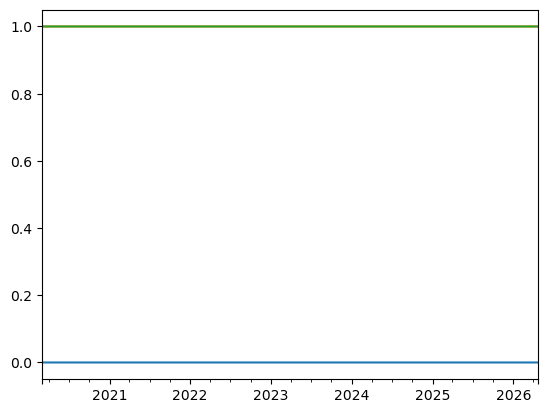

In [34]:
weights = weights.loc['2020-03-01':] # NOTE: Reliable data starts around 2020
print("Sum of abs weights (should be ~1):", weights.abs().sum(axis=1))
weights.sum(axis=1).plot()
weights.abs().sum(axis=1).plot()
print("count of days where weights don't equal 1:", (weights.abs().sum(axis=1) < 0.9).sum())

signal_fires = (weights.abs().sum(axis=1) > 0)

weights_held = weights.copy()
weights_held[~signal_fires] = np.nan
weights_held = weights_held.ffill()
weights_held = weights_held.fillna(0)

print("Non-zero weight bars (held):", (weights_held.abs().sum(axis=1) > 0).sum())
print("Original non-zero bars:", (weights.abs().sum(axis=1) > 0).sum())

weights_held.abs().sum(axis=1).plot()

## BACKTEST

1. Shift weights by 1 to avoid lookahead bias. 
  1. Weights computed using info at time t close are applied to the return of time t+1
1. We will only use days where weights = 1.

GROSS: ret_ann        1.179263
vol_ann        0.259132
sharpe         4.550815
max_dd        -0.800547
n_obs      13459.000000
dtype: float64
NET: ret_ann       -0.046882
vol_ann        0.257865
sharpe        -0.181808
max_dd        -0.975520
n_obs      13459.000000
dtype: float64
Mean turnover: 0.2799416812033624


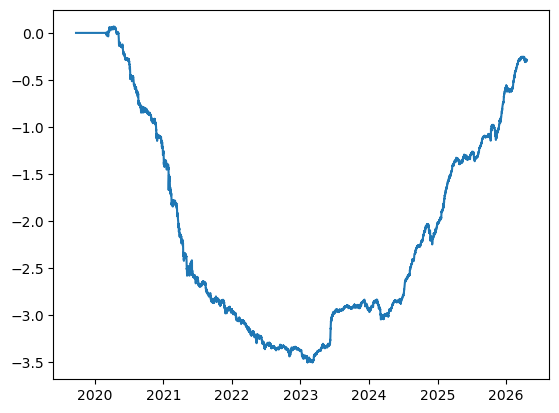

In [35]:
shifted_weights = weights_held.shift(1)
gross_ret = (shifted_weights * ret).sum(axis=1)
turnover = compute_turnover(weights_held)
net_ret = apply_costs(gross_ret, turnover)

valid = (weights_held.abs().sum(axis=1) > 0) & (~gross_ret.isna())
print("GROSS:", get_stats(gross_ret[valid], bars_per_year=BARS_PER_YEAR_4H))
print("NET:", get_stats(net_ret[valid], bars_per_year=BARS_PER_YEAR_4H))
print("Mean turnover:", turnover[valid].mean())

annual_ret = net_ret.cumsum()
plt.plot(annual_ret)

GROSS: ret_ann        0.156788
vol_ann        0.246789
sharpe         0.635313
max_dd        -0.726172
n_obs      13459.000000
dtype: float64
NET: ret_ann       -0.243049
vol_ann        0.247510
sharpe        -0.981978
max_dd        -0.890457
n_obs      13459.000000
dtype: float64
Mean turnover: 0.09128700721225291


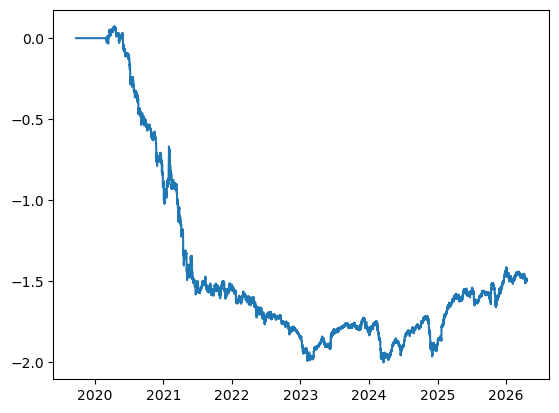

In [36]:
rebalance_every_n_bars = 6 # daily
weights_slow = weights_held.iloc[::rebalance_every_n_bars].reindex(weights_held.index, method='ffill')

shifted_weights_slow = weights_slow.shift(1)
gross_ret_slow = (shifted_weights_slow * ret).sum(axis=1)
turnover_slow = compute_turnover(weights_slow)
net_ret_slow = apply_costs(gross_ret_slow, turnover_slow)

valid_slow = (weights_slow.abs().sum(axis=1) > 0) & (~gross_ret_slow.isna())
print("GROSS:", get_stats(gross_ret_slow[valid_slow], bars_per_year=BARS_PER_YEAR_4H))
print("NET:", get_stats(net_ret_slow[valid_slow], bars_per_year=BARS_PER_YEAR_4H))
print("Mean turnover:", turnover_slow[valid_slow].mean())

annual_ret_slow = net_ret_slow.cumsum()
plt.plot(annual_ret_slow)

In [37]:
ann_by_year = net_ret[valid].groupby(net_ret[valid].index.year).agg(
    ['mean', 'std', 'count']
)
ann_by_year['sharpe'] = ann_by_year['mean']/ann_by_year['std'] * np.sqrt(BARS_PER_YEAR_4H)
print(ann_by_year)

          mean       std  count    sharpe
2020 -0.000699  0.006110   1836 -5.350561
2021 -0.000758  0.008604   2190 -4.121777
2022 -0.000196  0.003954   2190 -2.318134
2023  0.000197  0.003921   2190  2.350710
2024  0.000416  0.004213   2196  4.622085
2025  0.000666  0.005068   2190  6.147624
2026  0.000420  0.004107    667  4.783654


In [40]:
# BTC realized vol — 30-day rolling, annualized
btc_ret = ret['BTCUSDT']
btc_rvol = btc_ret.rolling(180, min_periods=90).std() * np.sqrt(BARS_PER_YEAR_4H)

# Inspect distribution — ONLY looking at 2020-2022 
is_series = btc_rvol.loc['2020-03-01':'2022-12-31']
print("BTC realized vol distribution 2020-2022:")
print(is_series.describe())
print(f"Median: {is_series.median():.3f}")
print(f"75th pct: {is_series.quantile(0.75):.3f}")


BTC realized vol distribution 2020-2022:
count    6216.000000
mean        0.692714
std         0.253682
min         0.219555
25%         0.532913
50%         0.665921
75%         0.760648
max         1.492993
Name: BTCUSDT, dtype: float64
Median: 0.666
75th pct: 0.761


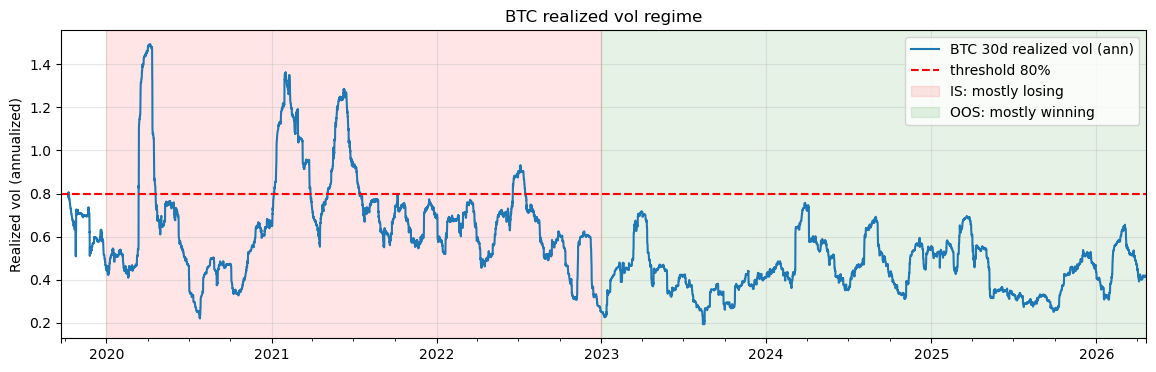

In [41]:
# Plot BTC realized vol over full sample with threshold line
fig, ax = plt.subplots(figsize=(14, 4))
btc_rvol.plot(ax=ax, label='BTC 30d realized vol (ann)')
ax.axhline(0.80, color='red', linestyle='--', label='threshold 80%')
ax.axvspan('2020-01-01', '2022-12-31', alpha=0.1, color='red', label='IS: mostly losing')
ax.axvspan('2023-01-01', '2026-12-31', alpha=0.1, color='green', label='OOS: mostly winning')
ax.set_ylabel('Realized vol (annualized)')
ax.set_title('BTC realized vol regime')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## Recap NOTES

What we've observed so far is reversal with a VOLUME gate at 0.7 has greate sharpe between 4 and 6 when you play with the gate threshold but terrible sharpe after factoring about 20 bps. Nothing you do here helps - reducing turnover by moving from intraday trades to daily trades still produces garbage returns and horrible sharpe. Removing the gate is much better. Here's why:

- Removing the gate means we aren't constantly rotating coins that test the 0.7 threshold consistently
- Looking at BTC volatility, you can see from 2020 to 2023 it constantly crosses and tests the 0.8 threshold
- Imagine if we did a similar analysis for all coins in the universe -> that's where we lose
- Removing the gate worked better but only shows returns post 2023
   - why? Look at the regimes
   - 2020 to 2023 has much more volatility for BTC compared to post-2023
   - It's not bull-run specific but it could be 
   - reversal works best in uninformed environments. during the 2020 to 2023 crypto and covid craze, there was nothing but informed trading
   - hype dies down -> reveral takes effect
   - We need to do a regime based filter and play around with a higher volatility (not volume) formation window
- the other thing is signal smoothing - we can't keep a hard threshold that requires us to trade often
- Anyways, sharpe for gross returns was 4.5 without the gate and got crushed by 20 bps to near 0. 
- Factoring in net of 20 bps in cost, sharpe collapses to -0.19 with a max DD of -0.97 (outrageous). Just horrible.
- BUT: the signal is still valid and the strategy is still profitable pre-2023

### Interpretations:
Interpretation 1: Crypto markets matured

2020-2022 was the "retail mania + meme era". Rallies crushed mean-reversion. Post-FTX (Nov 2022), crypto became more institutional and less FOMO-driven. In this new regime, cross-sectional reversal works the way it does in mature equity markets.

Supporting evidence: the inflection point (2022 → 2023) matches the FTX collapse and the crypto winter that followed.



Low vol regime (BTC < 0.8): 9357 bars
GROSS: ret_ann        1.123669
vol_ann        0.237191
sharpe         4.737404
max_dd        -0.439887
n_obs      13459.000000
dtype: float64
NET: ret_ann        0.284558
vol_ann        0.235924
sharpe         1.206140
max_dd        -0.657118
n_obs      13459.000000
dtype: float64
Mean turnover: 0.1915780566659676

Year-by-year NET Sharpe:
          mean       std  count    sharpe
2020 -0.000412  0.005444   1836 -3.543158
2021  0.000097  0.007246   2190  0.624419
2022 -0.000092  0.003793   2190 -1.139407
2023  0.000168  0.003871   2190  2.031114
2024  0.000307  0.004250   2196  3.385897
2025  0.000577  0.005041   2190  5.352363
2026  0.000285  0.004244    667  3.148259


<Axes: title={'center': 'Regime-gated Signal A: net cumsum'}>

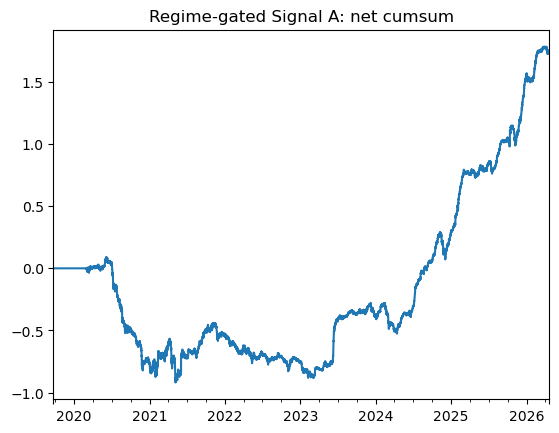

In [42]:
VOLUME_REGIME_BTC_THRESHOLD = 0.6

is_low_vol_regime = btc_rvol < VOLUME_REGIME_BTC_THRESHOLD
print("Low vol regime (BTC < 0.8):", is_low_vol_regime.sum(), "bars")

low_vol_signal = sig_raw.where(is_low_vol_regime, 0)

# Rank demean for portfolio construction weights
weights_regime = rank_demean_normalize(low_vol_signal, universe=universe)
weights_regime = weights_regime.loc['2020-03-01':]

# Forward fill for silent bars
non_zero_signal = (weights_regime.abs().sum(axis=1) > 0)
weights_regime_held = weights_regime.copy()
weights_regime_held[~non_zero_signal] = np.nan
weights_regime_held = weights_regime_held.ffill().fillna(0)

# Backtest

shifted_weights_regime = weights_regime_held.shift(1)
gross_ret_regime = (shifted_weights_regime * ret).sum(axis=1)
turnover_regime = compute_turnover(weights_regime_held)
net_regime = apply_costs(gross_ret_regime, turnover_regime)

valid_regime = (weights_regime_held.abs().sum(axis=1) > 0) & (~gross_ret_regime.isna())

print("GROSS:", get_stats(gross_ret_regime[valid_regime], bars_per_year=BARS_PER_YEAR_4H))
print("NET:", get_stats(net_regime[valid_regime], bars_per_year=BARS_PER_YEAR_4H))
print("Mean turnover:", turnover_regime[valid_regime].mean())

# Year-by-year Sharpe (the key diagnostic)
yb = net_regime[valid_regime].groupby(net_regime[valid_regime].index.year).agg(['mean','std','count'])
yb['sharpe'] = yb['mean']/yb['std'] * np.sqrt(BARS_PER_YEAR_4H)
print("\nYear-by-year NET Sharpe:")
print(yb)

# Also plot the net cumsum
net_regime.cumsum().plot(title='Regime-gated Signal A: net cumsum')

## Final In-Sample (IS) vs Out-Of-Sample (OOS) results

In [43]:
is_start, is_end = '2020-03-01', '2023-12-31'
oos_start = '2024-01-01'

is_net = net_regime[valid_regime & (net_regime.index >= is_start) & (net_regime.index <= is_end)]
oos_net = net_regime[valid_regime & (net_regime.index >= oos_start)]

def q_stats(r, label):
    print(f"{label}:")
    print(f"  n_obs: {len(r)}")
    print(f"  ret_ann: {r.mean() * BARS_PER_YEAR_4H:.3f}")
    print(f"  vol_ann: {r.std() * np.sqrt(BARS_PER_YEAR_4H):.3f}")
    print(f"  sharpe:  {r.mean()/r.std() * np.sqrt(BARS_PER_YEAR_4H):.3f}")

q_stats(is_net, "IS (2020-03 to 2023-12)")
q_stats(oos_net, "OOS (2024-01 onwards)")

IS (2020-03 to 2023-12):
  n_obs: 8401
  ret_ann: -0.099
  vol_ann: 0.247
  sharpe:  -0.400
OOS (2024-01 onwards):
  n_obs: 5053
  ret_ann: 0.922
  vol_ann: 0.216
  sharpe:  4.276


## Alpha/Beta Analysis and Correlation to BTC

In [44]:
# Full Sample 2020 to 2026
regression = factor_regression(net_regime, btc_ret, BARS_PER_YEAR_4H)
print("Full Sample:\n", regression)

is_start, is_end = '2020-03-01', '2023-12-31'
oos_start = '2024-01-01'

is_net = net_regime[valid_regime & (net_regime.index >= is_start) & (net_regime.index <= is_end)]
oos_net = net_regime[valid_regime & (net_regime.index >= oos_start)]

regression_is = factor_regression(is_net, btc_ret.loc[is_start:is_end], BARS_PER_YEAR_4H)
regression_oos = factor_regression(oos_net, btc_ret.loc[oos_start:], BARS_PER_YEAR_4H)

print("IS Regression:\n", regression_is)
print("OOS Regression:\n", regression_oos)

Full Sample:
 beta              0.012509
alpha_ann         0.259498
corr              0.033072
info_ratio        1.138954
n_obs         14416.000000
dtype: float64
IS Regression:
 beta             0.010483
alpha_ann       -0.105428
corr             0.028358
info_ratio      -0.427033
n_obs         8401.000000
dtype: float64
OOS Regression:
 beta             0.022748
alpha_ann        0.913867
corr             0.050514
info_ratio       4.241820
n_obs         5053.000000
dtype: float64


In [46]:
signal_a_v1_regime = {
    'weights_unshifted': weights_regime_held,
    'weights_shifted': shifted_weights_regime,
    'gross_regime': gross_ret_regime,
    'net_regime': net_regime,
    'turnover': turnover_regime,
    'gross_stats': get_stats(gross_ret_regime[valid_regime]),
    'net_stats': get_stats(net_regime[valid_regime])
}

pickle.dump(signal_a_v1_regime, open(os.path.join(PROJECT_DIR, 'data', 'signal_a_v1_regime.pkl'), 'wb'))

## Conclusion

Signal A was specified as volume-confirmed cross-sectional reversal with monthly-rebalanced universe and 4h portfolio rebalance. Initial testing falsified the volume-gate hypothesis: threshold sweeps showed the gate was subtracting signal, not adding it.

Without the gate, gross Sharpe was +4.5 but net Sharpe was -0.18 at 20bps market costs. Decomposing year-by-year revealed a strong regime break: the signal was deeply negative in 2020-2022 (crypto bull/collapse era) and strongly positive from 2023 onward.

A BTC realized-volatility regime filter was tested to explain the negative IS period. Adding a filter (signal off when BTC vol > 0.6) improved IS Sharpe from -3.9 to -1.0 and full-sample Sharpe to +1.21. However, the signal did not become IS-profitable at any tested threshold. The regime filter mitigates, but does not eliminate, Signal A's fragility to high-vol regimes.

Disposition: Signal A is marginally promising if combined with other uncorrelated signals. As a standalone, it fails IS validation at our 20bps cost assumption.

### Performance Evaluation:
```
beta              0.012509
alpha_ann         0.259498
corr              0.033072
info_ratio        1.138954
n_obs         14416.000000

Low vol regime (BTC < 0.6): 9357 bars
GROSS: ret_ann        1.123669
vol_ann        0.237191
sharpe         4.737404
max_dd        -0.439887
n_obs      13459.000000

NET: ret_ann        0.284558
vol_ann        0.235924
sharpe         1.206140
max_dd        -0.657118
n_obs      13459.000000

Mean turnover: 0.1915780566659676

Year-by-year NET Sharpe:
          mean       std  count    sharpe
2020 -0.000412  0.005444   1836 -3.543158
2021  0.000097  0.007246   2190  0.624419
2022 -0.000092  0.003793   2190 -1.139407
2023  0.000168  0.003871   2190  2.031114
2024  0.000307  0.004250   2196  3.385897
2025  0.000577  0.005041   2190  5.352363
2026  0.000285  0.004244    667  3.148259
```

Important notes:

1. Alpha is excellent at 0.2
2. The signal is very weakly correlated to BTC (0.033) — this is good
3. The signal has a very low beta (0.012) — this is also good
4. The signal has a very high information ratio (1.139) — this is also good
